# Dynamic Data Augmentation

Dynamic data augmentation applies transformations to images during training rather than beforehand. Unlike static augmentation—such as techniques used for dataset balancing—where modified images are preprocessed and stored, dynamic augmentation generates new variations in each training iteration. This approach improves model generalization by exposing it to a wider range of variations, reducing overfitting, and enhancing robustness.

We will explore two levels of data augmentation in a subset of the GTSRB:

- **Without increasing the dataset size**: Each image undergoes random transformations in every epoch, ensuring the model never sees the exact same image twice.

- **Expanding the dataset**: Multiple transformations are applied to each image, effectively increasing the dataset size by including different augmented versions.

In this notebook, we will apply some of the transformations explored in the previous notebook.

In [1]:
import torch
import torchvision
from torchvision.transforms import v2

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

## Auxiliary functions from previous classes

In [30]:
def show_bad_preds(model, dataset, classes):
    k = 0
    iters = 0

    preds = []
    ground_truth = []
    imgs = torch.Tensor(52, 3, 32,32)

    iterator = iter(dataset)

    max_iters = test_set.__len__() / BATCH_SIZE
    while k < 52 and iters < max_iters:

        images, targets = next(iterator)
        #print(images[0].shape)
        logits = model(images.to(device))
        
        #print(predictions[0])
        predictions = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
        for i in range(len(predictions)):

            if np.argmax(predictions[i]) != targets[i] and k < 52:

                preds.append(predictions[i])
                ground_truth.append(targets[i])
                imgs[k, :, :, :] = images[i]
                k += 1

        iters += 1

    vcpi_util.plot_predictions(imgs, preds, ground_truth, classes, 13, 4)




def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}
    history['accuracy'] = []
    history['val_acc'] = []
    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets) in enumerate(train_loader, 0):
            
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss
            correct += (predicted == targets).sum()

        model.eval()
        v_correct = 0
        val_loss = 0.0
        with torch.no_grad():
            for i,t in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)
                
                #with torch.no_grad():
                val_loss += loss_fn(o, t)

                v_correct += (p == t).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; Val Loss: {val_loss:0.6f}; Val Acc: {v_accuracy:0.4f}; Elapsed time: {(stop_time - start_time):0.4f}')
        history['accuracy'].append(accuracy.cpu().numpy())
        history['val_acc'].append(v_accuracy.cpu().numpy())
        history['val_loss'].append(val_loss.cpu().detach().numpy())
        history['loss'].append(epoch_loss.cpu().detach().numpy())
 
        ###### Saving ######
        if val_loss < best_val_loss:
           
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}_best.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)


def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    
    for i, (images, targets) in enumerate(data_loader):
         
        # forward pass, compute the output of the model for the current batch
        outputs = model(images.to(device))

        # "max" returns a namedtuple (values, indices) where values is the maximum 
        # value of each row of the input tensor in the given dimension dim; 
        # indices is the index location of each maximum value found (argmax).
        # the argmax effectively provides the predicted class number        
        _, preds = torch.max(outputs, dim=1)

        correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()


class Conv(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, 3)
        self.bn1 = torch.nn.BatchNorm2d(16)
        self.relu1 = torch.nn.ReLU()

        self.conv2 = torch.nn.Conv2d(16, 32, 3)
        self.bn2 = torch.nn.BatchNorm2d(32)
        self.relu2 = torch.nn.ReLU()

        self.maxpool1 = torch.nn.MaxPool2d(2)


        self.conv3 = torch.nn.Conv2d(32, 48, 3)
        self.bn3 = torch.nn.BatchNorm2d(48)
        self.relu3 = torch.nn.ReLU()

        self.conv4 = torch.nn.Conv2d(48, 48, 3)
        self.bn4 = torch.nn.BatchNorm2d(48)
        self.relu4 = torch.nn.ReLU()

        self.maxpool2 = torch.nn.MaxPool2d(2)

        self.fc1 = torch.nn.Linear(1200, num_classes)
        

    def forward(self, x):    
        
        # input = (bs, 3, 32, 32)
        x = self.conv1(x) # -> (bs, 16, 26, 26)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x) # -> (bs, 32, 24, 24)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.maxpool1(x)
        
        x = self.conv3(x) # -> (bs, 48, 22, 22)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.conv4(x) # -> (bs, 48, 20, 20)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.maxpool2(x)
        
        x = torch.flatten(x,1) # -> (bs, 48 * 20 * 20 = 1920)
        x = self.fc1(x)        # -> (bs, 10)

        return(x)



class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    


def build_confusion_matrix(model, dataset):

    preds = []
    ground_truth = []

    for images, targets in dataset:

        predictions = model(images.to(device))
        preds_sparse = [np.argmax(x) for x in predictions.cpu().detach().numpy()]
        preds.extend(preds_sparse)
        ground_truth.extend(targets.numpy())

    vcpi_util.show_confusion_matrix(ground_truth, preds, len(test_set.classes))      


## Settings

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BASE_PATH = 'd:/vcpi/gtsrb'

PATH_TRAINING_SET = f'{BASE_PATH}/train_balanced_2000'
PATH_TEST_SET = f'{BASE_PATH}/test_A'
PATH_VAL_SET = f'{BASE_PATH}/val'

BATCH_SIZE = 32

EPOCHS = 50

RUNS = 5

cuda:0


In [16]:
transform = v2.Compose(
    [v2.Resize((32,32)), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

# No shuffle is required for the test set, also the batch size can be completely different
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE)

val_set = torchvision.datasets.ImageFolder(root=PATH_VAL_SET, transform = transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

## Previous accuracy performance

show accuracies for models trained with data augmentation from balancing the dataset

In [5]:
res = 0
model_Conv = Conv(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'gtsrb_balanced_{i}_best.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)    
    res += eval

res /= RUNS    
print(res)

25 0.9882494211196899 0.9813953638076782
24 0.9892086386680603 0.9817829728126526
37 0.9892086386680603 0.9794573783874512
24 0.9894484281539917 0.9864341020584106
20 0.9877697825431824 0.986821711063385
0.9887769818305969


## Data augmentation
 
### Setting up a transform for dynamic data augmentation

In [15]:
transform_aug = v2.Compose(
    [v2.Resize((32,32)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05], interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ColorJitter(brightness = 0.5, contrast = 0.5,hue = 0.1),
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform_aug)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

### Training

In [49]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(1):
    model_Conv_II = Conv(len(train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'aug_I_{i}')

Epoch: 000; Loss: 0.025793; Accuracy: 71.0625; Val Loss: 0.007084; Val Acc: 92.2868; Elapsed time: 17.0094
Epoch: 001; Loss: 0.005296; Accuracy: 94.9063; Val Loss: 0.004067; Val Acc: 96.0853; Elapsed time: 17.0385
Epoch: 002; Loss: 0.003330; Accuracy: 96.6125; Val Loss: 0.002874; Val Acc: 97.2868; Elapsed time: 16.9391
Epoch: 003; Loss: 0.002167; Accuracy: 97.9250; Val Loss: 0.002680; Val Acc: 97.0930; Elapsed time: 16.9175
Epoch: 004; Loss: 0.002053; Accuracy: 97.7625; Val Loss: 0.002331; Val Acc: 97.4806; Elapsed time: 16.8787
Epoch: 005; Loss: 0.001880; Accuracy: 98.1500; Val Loss: 0.001867; Val Acc: 97.9845; Elapsed time: 16.9441
Epoch: 006; Loss: 0.001477; Accuracy: 98.5188; Val Loss: 0.003192; Val Acc: 96.2016; Elapsed time: 16.8705
Epoch: 007; Loss: 0.001348; Accuracy: 98.5750; Val Loss: 0.002221; Val Acc: 97.2481; Elapsed time: 16.8599
Epoch: 008; Loss: 0.001243; Accuracy: 98.7375; Val Loss: 0.003672; Val Acc: 96.3953; Elapsed time: 16.8788
==> Learning rate updated:  0.001  ->

### Evaluating

In [32]:
res = 0
model_Conv = Conv(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_I_{i}_best.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)
    res += eval

res /= RUNS    
print(res)

42 0.9947242140769958 0.9872093200683594
34 0.9947242140769958 0.9976744055747986
30 0.9947242140769958 0.9906976819038391
26 0.9968824982643127 0.9903100728988647
22 0.9944844245910645 0.9941860437393188
0.995107913017273


Show misclassifications for the last model

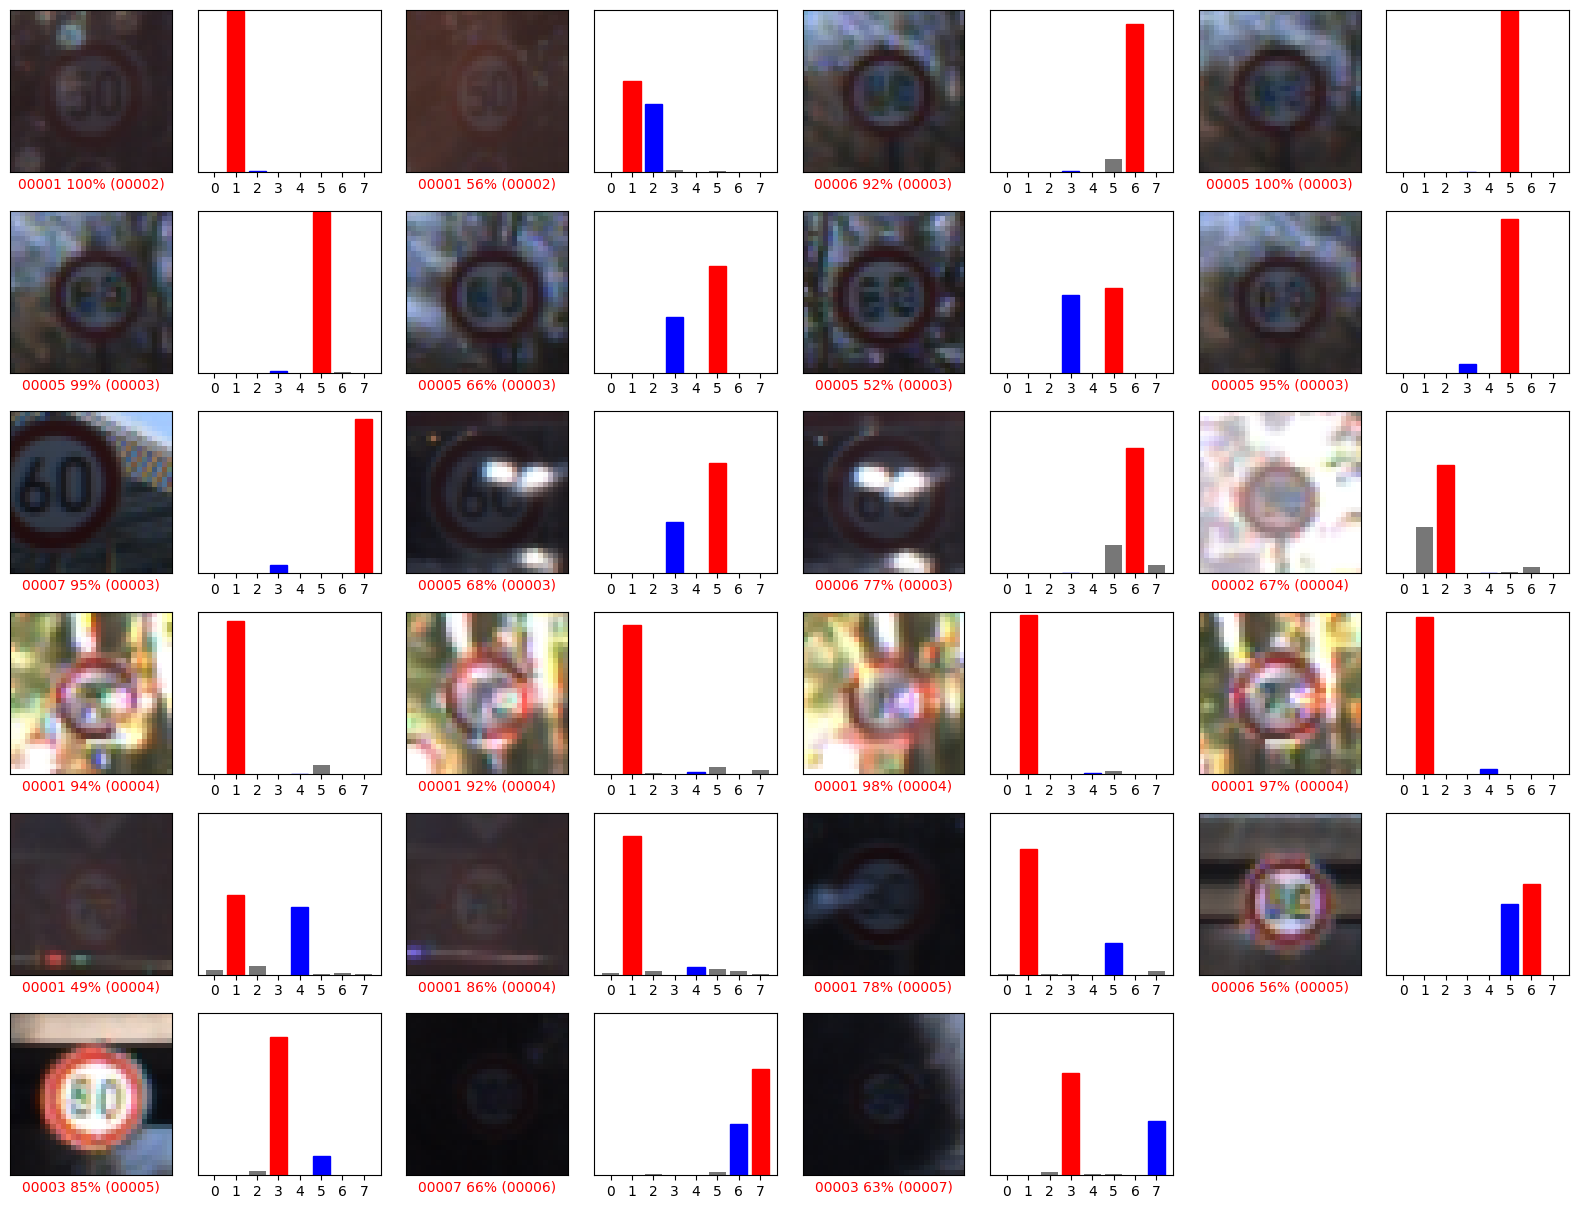

In [33]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

## Massive Data Augmentation

Here, we will significantly expand the dataset by applying multiple transformations in combination.

### Setting the transform

In [8]:
transform_A = v2.Compose(
    [v2.Resize((32,32)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05],interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

transform_B = v2.Compose(
    [v2.Resize((32,32)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05],interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ColorJitter(brightness = 0.5), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

transform_C = v2.Compose(
     [v2.Resize((32,32)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05],interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ColorJitter(contrast = 0.5), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)])

transform_D = v2.Compose(
     [v2.Resize((32,32)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05],interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ColorJitter(hue = 0.1), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)])    



train_loader = torch.utils.data.DataLoader(
    torch.utils.data.ConcatDataset([   
        torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform=transform_A),
        torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform=transform_B),
        torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform=transform_C),
        torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform=transform_D),
    ]),  batch_size = BATCH_SIZE, shuffle = True)

#train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform_A)
#train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

### Training

In [44]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_III = Conv(len(train_set.classes))
    model_Conv_III.to(device)

    early_stop = Early_Stopping(9)
    optimizer_III = torch.optim.Adam(model_Conv_III.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_III, mode='min', factor = 0.1, patience=3)

    history_III = train_III(model_Conv_III, train_loader , val_loader, EPOCHS, loss_fn, optimizer_III, scheduler, early_stop, f'aug_II_{i}')

Epoch: 000; Loss: 0.006589; Accuracy: 93.0813; Val Loss: 0.002320; Val Acc: 97.6357; Elapsed time: 51.7696
Epoch: 001; Loss: 0.001095; Accuracy: 98.8203; Val Loss: 0.002164; Val Acc: 97.7519; Elapsed time: 52.1077
Epoch: 002; Loss: 0.000768; Accuracy: 99.2453; Val Loss: 0.001893; Val Acc: 98.0233; Elapsed time: 51.5289
Epoch: 003; Loss: 0.000596; Accuracy: 99.3906; Val Loss: 0.000853; Val Acc: 99.1085; Elapsed time: 51.7543
Epoch: 004; Loss: 0.000475; Accuracy: 99.5203; Val Loss: 0.001545; Val Acc: 98.5271; Elapsed time: 51.8526
Epoch: 005; Loss: 0.000386; Accuracy: 99.5984; Val Loss: 0.001967; Val Acc: 98.3333; Elapsed time: 51.6742
Epoch: 006; Loss: 0.000308; Accuracy: 99.6844; Val Loss: 0.001374; Val Acc: 98.6047; Elapsed time: 52.2815
==> Learning rate updated:  0.001  ->  0.0001
Epoch: 007; Loss: 0.000352; Accuracy: 99.6609; Val Loss: 0.002752; Val Acc: 97.8682; Elapsed time: 52.5694
Epoch: 008; Loss: 0.000072; Accuracy: 99.9250; Val Loss: 0.000619; Val Acc: 99.4186; Elapsed time:

### Evaluating

In [34]:
res = 0
model_Conv = Conv(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_II_{i}_best.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)    
    res += eval

res /= RUNS    
print(res)

19 0.9944844245910645 0.9937984347343445
32 0.9956834316253662 0.9926356673240662
14 0.9956834316253662 0.9918604493141174
19 0.9944844245910645 0.9934108257293701
24 0.9956834316253662 0.9957364201545715
0.9952038288116455


Show misclassifications for the last model

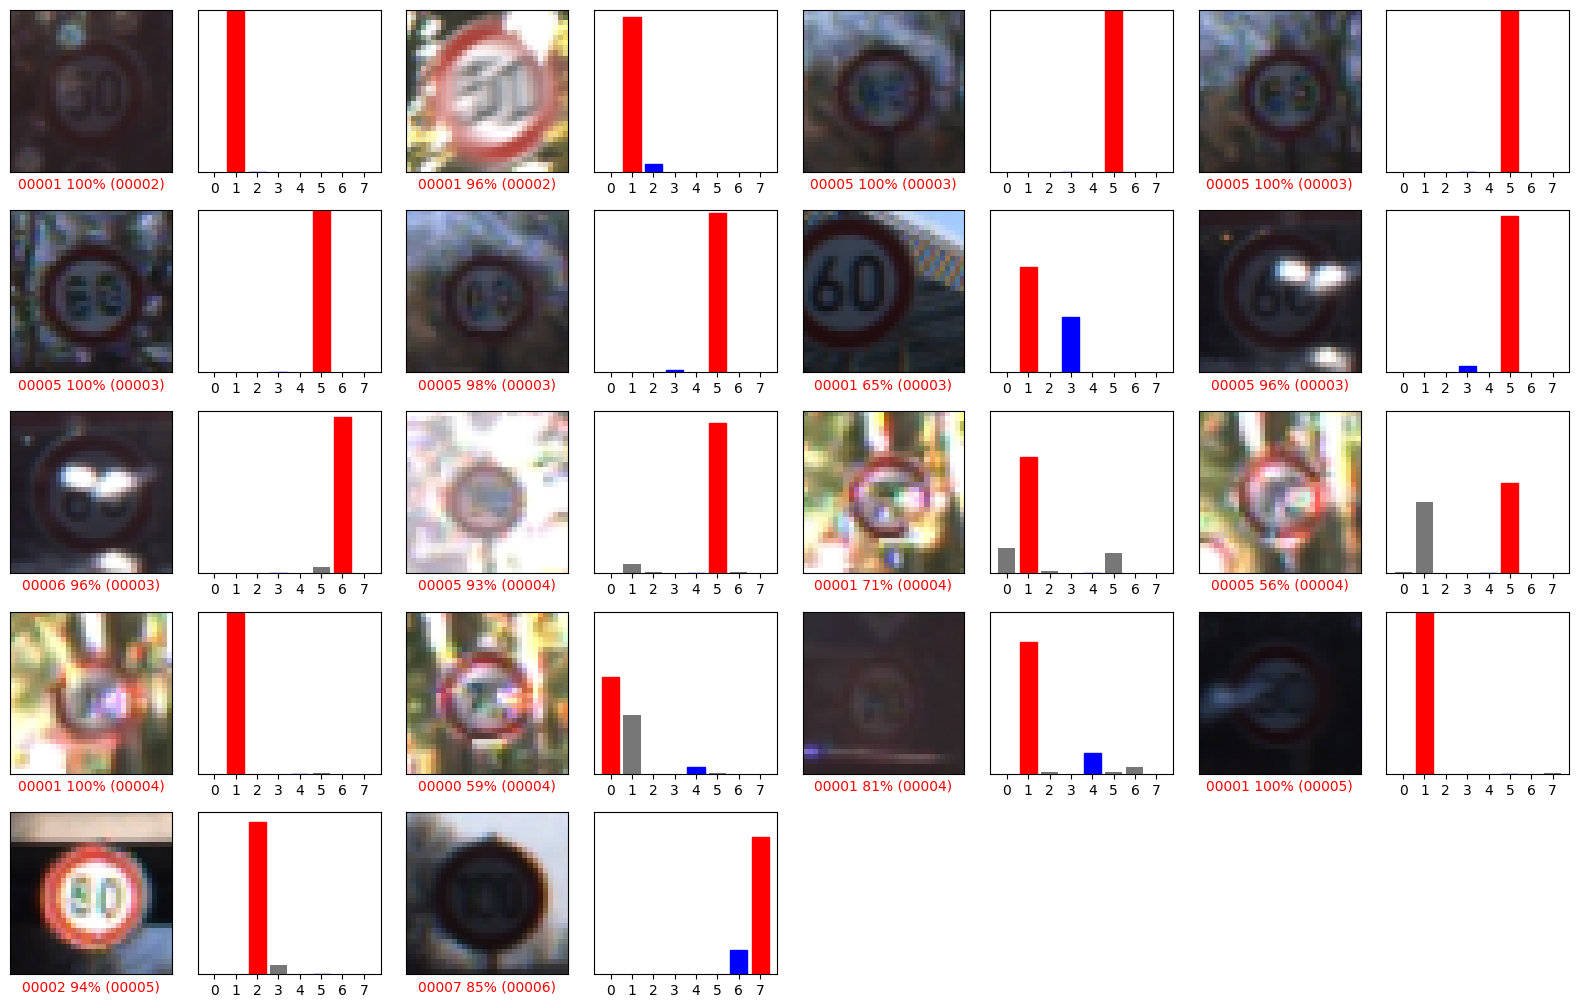

In [31]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

# Testing on traffic signs from other datasets

## rMASTIF (Croatian dataset)

The Croatian dataset has traffic signs with speed limits, but only for 30, 50, 60,  and 70 km/h

The dataset can be download [here](https://www.zemris.fer.hr/~kalfa/Datasets/rMASTIF/)

In [10]:
test_set = torchvision.datasets.ImageFolder(root='d:/vcpi/croatian_test_common', transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE)


In [11]:
res = 0
model_Conv = Conv(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_I_{i}_best.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)
    res += eval

res /= RUNS    
print(res)

42 0.9922600388526917 0.9872093200683594
34 0.99071204662323 0.9976744055747986
30 0.9918730854988098 0.9906976819038391
26 0.9941950440406799 0.9903100728988647
22 0.9914860725402832 0.9941860437393188
0.9921052575111389


In [12]:
res = 0
model_Conv = Conv(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_II_{i}_best.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)    
    res += eval

res /= RUNS    
print(res)

19 0.9914860725402832 0.9937984347343445
32 0.9949690699577332 0.9926356673240662
14 0.9934210777282715 0.9918604493141174
19 0.9918730854988098 0.9934108257293701
24 0.9926470518112183 0.9957364201545715
0.9928792715072632


# BTSC (Belgian Traffic Sign Classification)

The BTSC has traffic signs with speed limits, but only for 30, 50, and 70 km/h

BTSC can be downloaded [here](https://btsd.ethz.ch/shareddata/)

In [90]:
test_set = torchvision.datasets.ImageFolder(root='d:/vcpi/belgium_test_common', transform = transform, target_transform = None)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE)

In [95]:
res = 0
model_Conv = Conv(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_I_{i}_best.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)
    res += eval

res /= RUNS    
print(res)

42 0.9833729267120361 0.9872093200683594
34 0.9833729267120361 0.9976744055747986
30 0.9548693299293518 0.9906976819038391
26 0.9714964628219604 0.9903100728988647
22 0.978622317314148 0.9941860437393188
0.9743467926979065


In [92]:
res = 0
model_Conv = Conv(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_II_{i}_best.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)    
    res += eval

res /= RUNS    
print(res)

19 0.9857482314109802 0.9937984347343445
32 0.980997622013092 0.9926356673240662
14 0.978622317314148 0.9918604493141174
19 0.980997622013092 0.9934108257293701
24 0.9833729267120361 0.9957364201545715
0.9819477438926697


Note: the stop signs that may appear in the images below are due to the fact that this version of pytorch does not accept empty folders in the dataset.

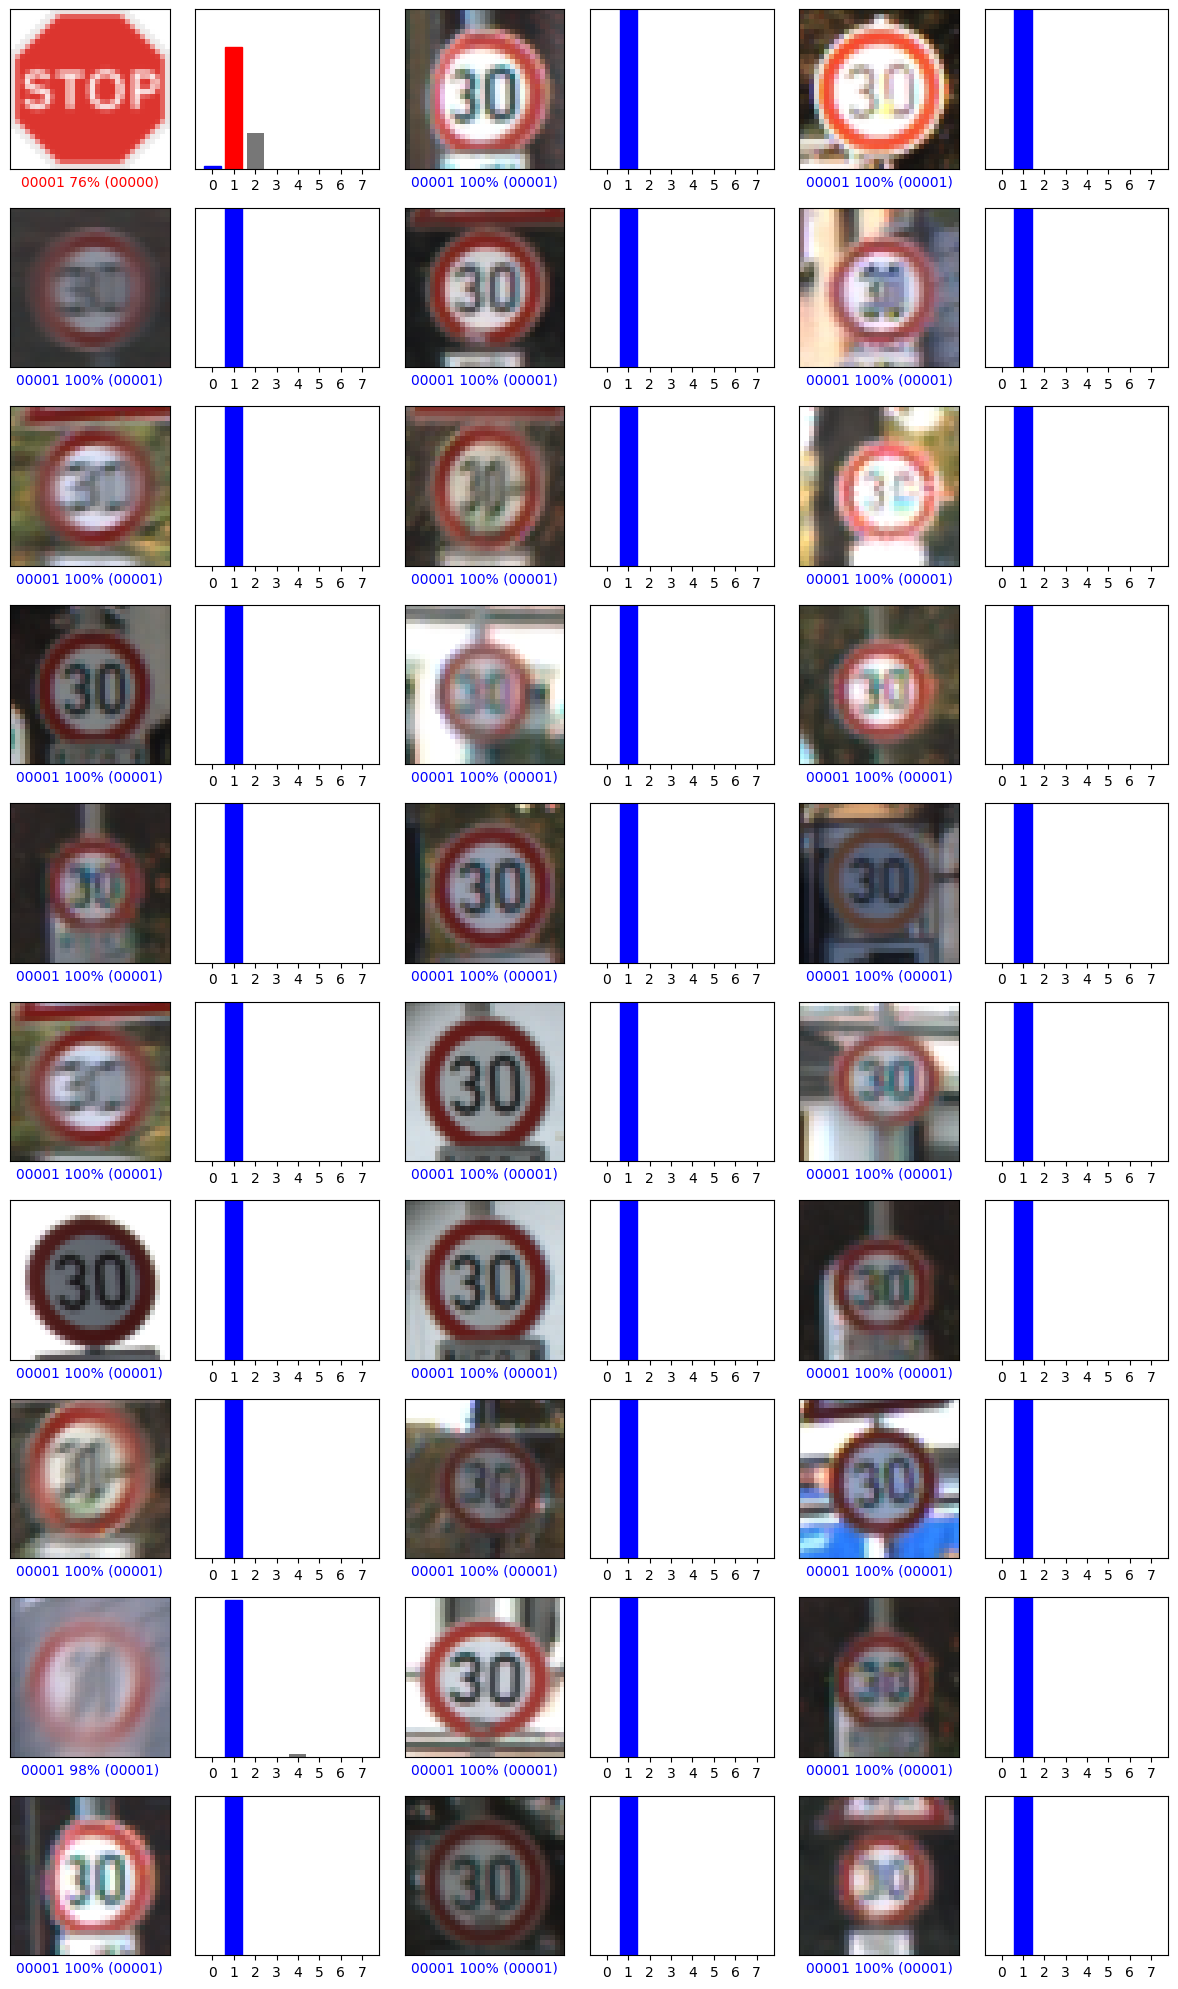

In [ ]:
images, targets = next(iter(test_loader))
model_Conv.eval()
logits = model_Conv(images.to(device))

predictions = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
vcpi_util.plot_predictions(images, predictions, targets, train_set.classes, 10, 3)

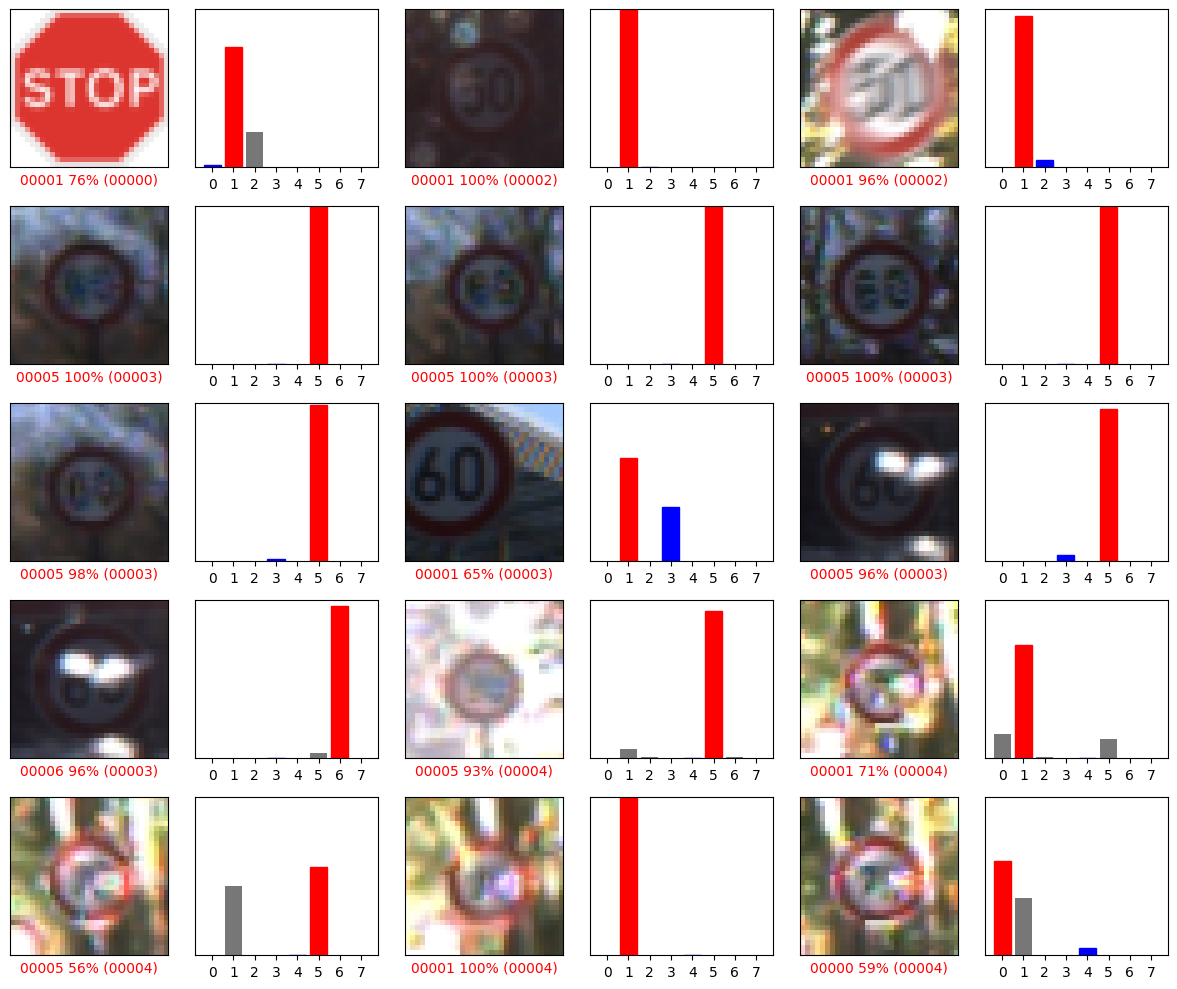

In [14]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   